In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [7]:
data = pd.read_csv('ecommerce_bigdata.csv')
data.head()
data.info()

missing_values = data.isnull().sum()
print(f"Missing Values: {missing_values}")

data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    200 non-null    str    
 1   Date             200 non-null    str    
 2   Region           200 non-null    str    
 3   ProductCategory  200 non-null    str    
 4   CustomerType     200 non-null    str    
 5   Sales            200 non-null    int64  
 6   Profit           200 non-null    float64
dtypes: float64(1), int64(1), str(5)
memory usage: 11.1 KB
Missing Values: TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64


,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


Text(0, 0.5, 'Sales')

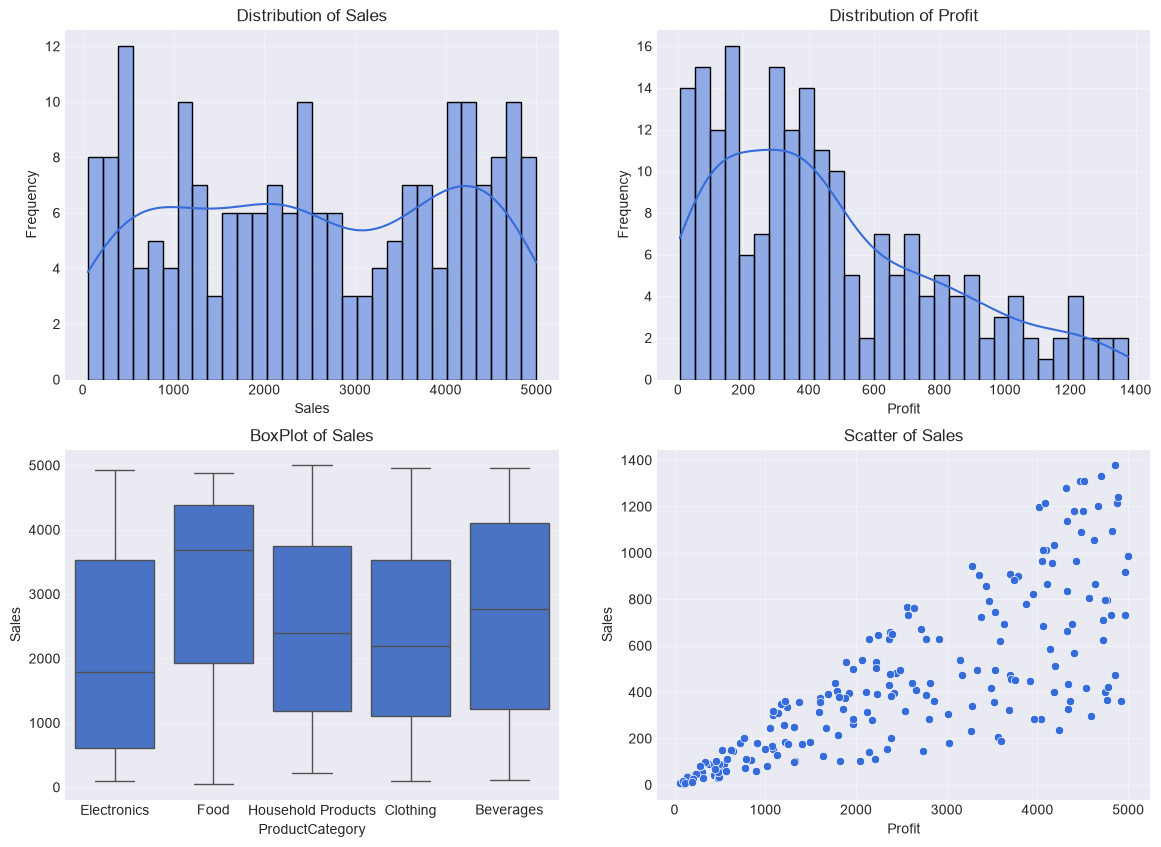

In [15]:
#Data Visualizations

plt.style.use('seaborn-v0_8-darkgrid')

fig,axes = plt.subplots(2,2,figsize=(14,10))

sns.histplot(data['Sales'], bins = 30, kde=True ,ax = axes[0,0])
axes[0, 0].set_title('Distribution of Sales')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(data['Profit'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Profit')
axes[0, 1].set_xlabel('Profit')
axes[0, 1].set_ylabel('Frequency')


sns.boxplot(x = data['ProductCategory'], y=data['Sales'], ax = axes[1, 0])
axes[1, 0].set_title('BoxPlot of Sales')
axes[1, 0].set_xlabel('ProductCategory')
axes[1, 0].set_ylabel('Sales')


sns.scatterplot(x = data['Sales'], y=data['Profit'], ax = axes[1, 1])
axes[1, 1].set_title('Scatter of Sales')
axes[1, 1].set_xlabel('Profit')
axes[1, 1].set_ylabel('Sales')


In [16]:
data_copy = data.copy()

data_copy['Date'] = pd.to_datetime(data_copy['Date'])
data_copy['Month'] = data_copy['Date'].dt.month
data_copy['Day'] = data_copy['Date'].dt.day
data_copy['Year'] = data_copy['Date'].dt.year
data_copy['Weekday'] = data_copy['Date'].dt.weekday


print(data_copy)

    TransactionID       Date    Region     ProductCategory CustomerType  \
0          TX0001 2026-06-16   Eastern         Electronics    Wholesale   
1          TX0002 2026-02-12   Central         Electronics       Retail   
2          TX0003 2026-03-01  Northern                Food       Online   
3          TX0004 2026-06-03   Western  Household Products       Online   
4          TX0005 2026-01-21   Western  Household Products       Retail   
..            ...        ...       ...                 ...          ...   
195        TX0196 2026-05-17   Eastern  Household Products       Online   
196        TX0197 2026-05-23   Eastern            Clothing    Wholesale   
197        TX0198 2026-01-12  Northern            Clothing       Online   
198        TX0199 2026-06-14   Western  Household Products       Retail   
199        TX0200 2026-03-18   Western           Beverages       Retail   

     Sales   Profit  Month  Day  Year  Weekday  
0     4924   359.44      6   16  2026        1  
1